<a href="https://colab.research.google.com/github/senBenz/ML/blob/main/TP_ML_5_Mini_Projets_Complet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP Machine Learning — 5
 Mini-Projets

---



Ce notebook contient :
1. KNN — Clients Premium
2. Arbre de Décision — Réussite Étudiants
3. Naive Bayes — Spam Email
4. SVM — Classification Fruits


# 🧠 Mini-Projet 1 — KNN : Clients Premium

**TP Machine Learning – Mini Projet : Classification avec K-Nearest Neighbors (KNN)**

### Contexte

Une entreprise souhaite identifier si un client est **Premium** ou **Non Premium** à partir de plusieurs caractéristiques telles que l’âge, le revenu et la ville.

On dispose d’un dataset contenant ces informations ainsi qu’une variable cible **Premium** :

* **0** → Client Non Premium
* **1** → Client Premium

L’objectif est de construire un modèle de **classification K-Nearest Neighbors (KNN)** permettant de prédire si un client est Premium.

---

### Travail demandé

#### 1. Préparation des données

1. Charger le dataset `mini_projet_1_clients.csv`.
2. Traiter les valeurs manquantes éventuelles.
3. Encoder les variables catégorielles si nécessaire (ex : ville).
4. Séparer les variables explicatives **X** et la variable cible **y (Premium)**.

---

#### 2. Séparation des données

Diviser le dataset en deux parties :

* **70 %** pour l’entraînement
* **30 %** pour le test

Utiliser l’option `stratify=y` afin de conserver la même proportion de classes dans les deux ensembles.

---

#### 3. Standardisation des données

Appliquer une **standardisation (StandardScaler)** sur les variables explicatives.

Justifier pourquoi cette étape est importante pour l’algorithme **KNN**.

---

#### 4. Choix du paramètre K

Tester plusieurs valeurs de **K (de 1 à 30)** :

1. Entraîner le modèle pour chaque valeur de K.
2. Calculer l’**accuracy** sur l’ensemble de test.
3. Identifier la valeur **optimale de K**.
4. Tracer la courbe :

**Accuracy en fonction de K**

---

#### 5. Évaluation du modèle final

En utilisant la meilleure valeur de **K** :

1. Entraîner le modèle final.
2. Calculer la **matrice de confusion**.
3. Afficher le **classification report** (Precision, Recall, F1-score).

Interpréter les résultats obtenus pour les deux classes (0 et 1).

---

#### 6. Analyse par visualisation

Réaliser les visualisations suivantes :

1. **Distribution des labels (0 vs 1)** dans le dataset.
2. **Projection PCA en 2 dimensions** des données test avec :

   * couleur = vrai label
3. **Projection PCA avec :**

   * couleur = prédiction du modèle
4. **Projection PCA des erreurs**
   (1 = erreur de classification, 0 = prédiction correcte)
5. **Histogramme des probabilités prédites** pour chaque classe.
6. **Graphique Precision / Recall / F1-score par classe.**

---

#### 7. Interprétation

À partir des résultats obtenus :

* Analyser la capacité du modèle à détecter les **clients Premium**.
* Identifier les **types d’erreurs** réalisées par le modèle.
* Expliquer la relation entre les erreurs observées et la **distribution des données dans l’espace PCA**.

---

### Objectif pédagogique

Ce mini-projet permet de comprendre les étapes fondamentales d’un projet de Machine Learning :

* Préparation des données
* Entraînement d’un modèle KNN
* Optimisation d’un hyperparamètre
* Évaluation avec plusieurs métriques
* Analyse visuelle des performances du modèle


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


✅ Meilleur K = 1 | Accuracy(test) = 0.8333


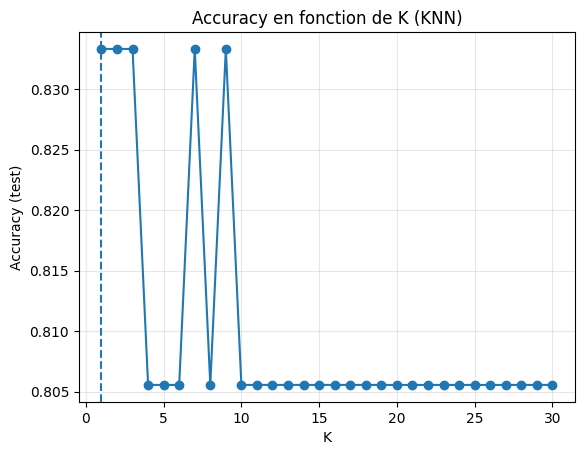


📌 Accuracy finale: 0.8333333333333334


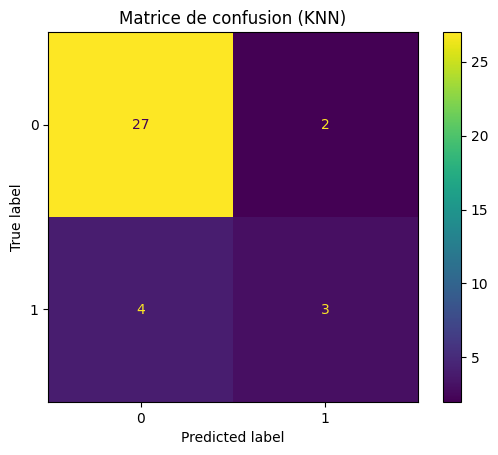


📌 Classification report :

              precision    recall  f1-score   support

           0       0.87      0.93      0.90        29
           1       0.60      0.43      0.50         7

    accuracy                           0.83        36
   macro avg       0.74      0.68      0.70        36
weighted avg       0.82      0.83      0.82        36



<Figure size 640x480 with 0 Axes>

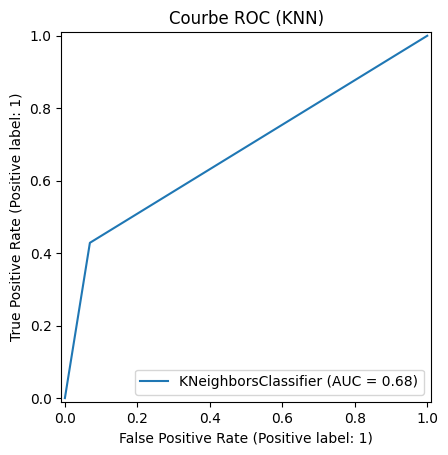

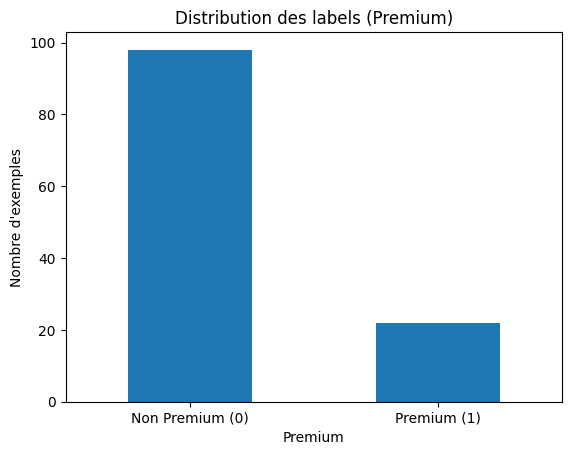

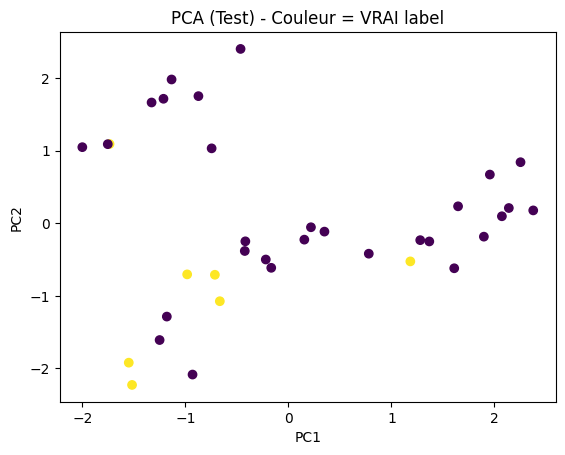

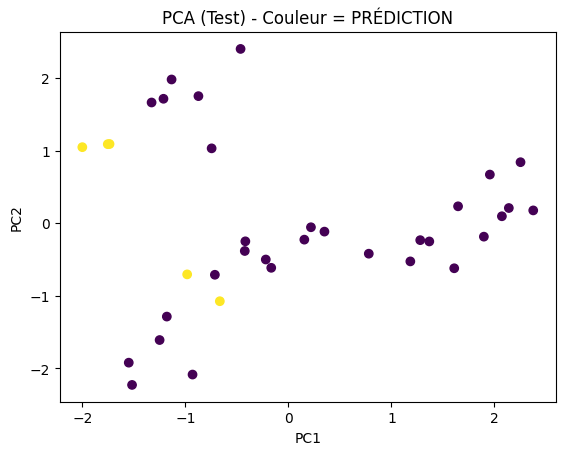

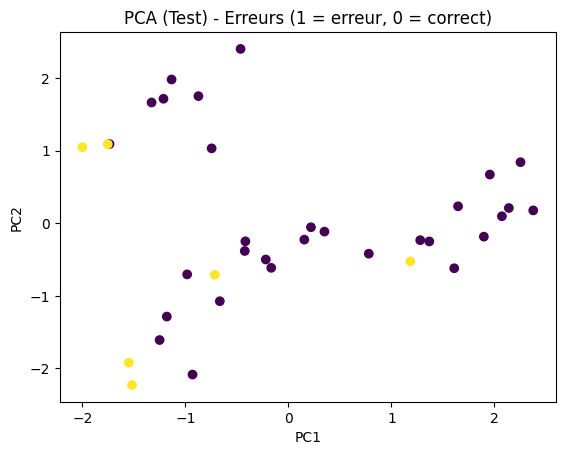

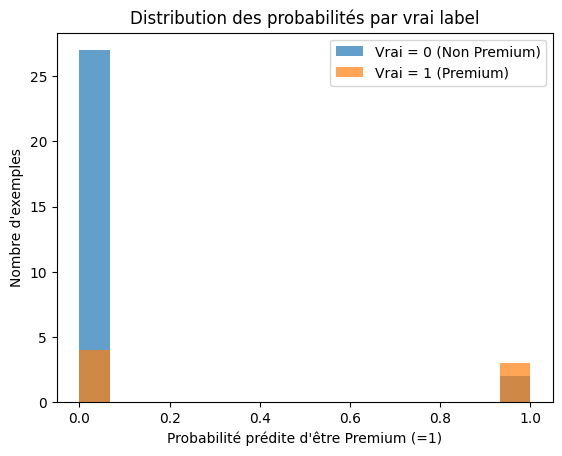

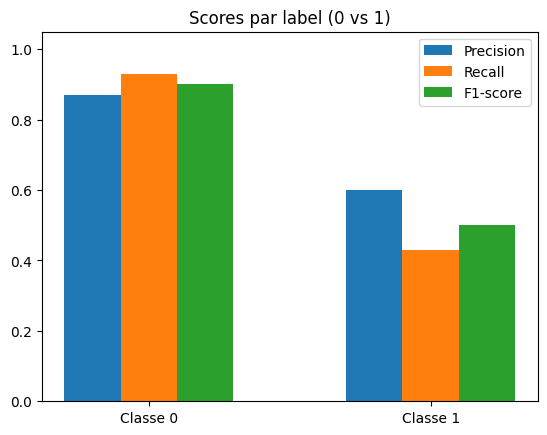

In [5]:
# =========================
# KNN complet (préparation + choix K + évaluation + plots par labels)
# =========================

import pandas as pd
path = "/content/drive/MyDrive/mini_projet_1_clients.csv"
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, RocCurveDisplay, precision_recall_fscore_support
)
from sklearn.decomposition import PCA

# =========================
# 1) Chargement + Préparation
# =========================


data = pd.read_csv(path)


# Imputation simple
data["Revenu"] = data["Revenu"].fillna(data["Revenu"].mean())

# One-hot encoding
data = pd.get_dummies(data, columns=["Ville"], drop_first=True)

# Séparation X / y
X = data.drop("Premium", axis=1)
y = data["Premium"]

# Split train/test (stratify pour garder les proportions 0/1)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Standardisation (IMPORTANT pour KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================
# 2) Choix de K (Accuracy vs K)
# =========================
k_values = range(1, 31)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    y_pred_tmp = model.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, y_pred_tmp))

best_k = list(k_values)[int(np.argmax(accuracies))]
best_acc = max(accuracies)

print(f"✅ Meilleur K = {best_k} | Accuracy(test) = {best_acc:.4f}")

plt.figure()
plt.plot(list(k_values), accuracies, marker="o")
plt.axvline(best_k, linestyle="--")
plt.xlabel("K")
plt.ylabel("Accuracy (test)")
plt.title("Accuracy en fonction de K (KNN)")
plt.grid(True, alpha=0.3)
plt.show()

# =========================
# 3) Modèle final avec best_k
# =========================
final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X_train_scaled, y_train)
y_pred = final_model.predict(X_test_scaled)

acc_final = accuracy_score(y_test, y_pred)
print("\n📌 Accuracy finale:", acc_final)

# =========================
# 4) Matrice de confusion
# =========================
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Matrice de confusion (KNN)")
plt.show()

# =========================
# 5) Classification report
# =========================
print("\n📌 Classification report :\n")
print(classification_report(y_test, y_pred))

# =========================
# 6) Courbe ROC
# =========================
plt.figure()
RocCurveDisplay.from_estimator(final_model, X_test_scaled, y_test)
plt.title("Courbe ROC (KNN)")
plt.show()

# =========================

# =========================
# 7) Plots PAR LABELS (0 vs 1)
# =========================

# A) Répartition des classes
plt.figure()
y.value_counts().sort_index().plot(kind="bar")
plt.xticks([0, 1], ["Non Premium (0)", "Premium (1)"], rotation=0)
plt.ylabel("Nombre d'exemples")
plt.title("Distribution des labels (Premium)")
plt.show()

# B) PCA 2D - Couleur = vrai label
pca = PCA(n_components=2)
X_test_2d = pca.fit_transform(X_test_scaled)

plt.figure()
plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA (Test) - Couleur = VRAI label")
plt.show()

# C) PCA 2D - Couleur = prédiction
plt.figure()
plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_pred)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA (Test) - Couleur = PRÉDICTION")
plt.show()

# D) PCA - afficher seulement les erreurs (y_pred != y_test)
errors = (y_pred != y_test.to_numpy())

plt.figure()
plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=errors.astype(int))
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA (Test) - Erreurs (1 = erreur, 0 = correct)")
plt.show()

# E) Histogramme des probabilités par vrai label
y_proba = final_model.predict_proba(X_test_scaled)[:, 1]

plt.figure()
plt.hist(y_proba[y_test == 0], bins=15, alpha=0.7, label="Vrai = 0 (Non Premium)")
plt.hist(y_proba[y_test == 1], bins=15, alpha=0.7, label="Vrai = 1 (Premium)")
plt.xlabel("Probabilité prédite d'être Premium (=1)")
plt.ylabel("Nombre d'exemples")
plt.title("Distribution des probabilités par vrai label")
plt.legend()
plt.show()

# F) Precision / Recall / F1 par classe (plot)
prec, rec, f1, sup = precision_recall_fscore_support(y_test, y_pred, labels=[0, 1])

plt.figure()
x = np.arange(2)
plt.bar(x - 0.2, prec, width=0.2, label="Precision")
plt.bar(x,       rec,  width=0.2, label="Recall")
plt.bar(x + 0.2, f1,   width=0.2, label="F1-score")
plt.xticks(x, ["Classe 0", "Classe 1"])
plt.ylim(0, 1.05)
plt.title("Scores par label (0 vs 1)")
plt.legend()
plt.show()

# 🌳 Mini-Projet 2 — Arbre de Décision : Réussite Étudiants


**TP Machine Learning – Exercice 2 : Classification avec Arbre de Décision**

### Contexte

Une université souhaite prédire si un étudiant va **réussir ou échouer** à un examen final à partir de plusieurs caractéristiques académiques.

On dispose d’un dataset `mini_projet_2_etudiants.csv` contenant des informations telles que :

* Moyenne générale
* Nombre d’heures d’étude
* Taux d’absentéisme
* Participation en classe

La variable cible est :

* **Resultat = 1** → Réussite
* **Resultat = 0** → Échec

L’objectif est de construire un **modèle de classification basé sur un Arbre de Décision**.

---

### Travail demandé

#### 1. Chargement des données

1. Charger le dataset avec **pandas**.
2. Séparer les variables :

   * **X** : caractéristiques des étudiants
   * **y** : variable cible (Resultat).

---

#### 2. Séparation Train / Test

Diviser les données :

* **70 % pour l’entraînement**
* **30 % pour le test**

Utiliser `stratify=y` afin de conserver la proportion réussite / échec.

---

#### 3. Choix du paramètre `max_depth`

Un arbre trop profond peut provoquer du **surapprentissage**.

1. Tester plusieurs valeurs de **max_depth (1 à 20)**.
2. Pour chaque profondeur :

   * entraîner le modèle
   * calculer l’accuracy sur train
   * calculer l’accuracy sur test
   * calculer l’accuracy moyenne avec **validation croisée (5-fold)**.
3. Tracer un graphique :

**Accuracy vs max_depth**

---

#### 4. Sélection du meilleur modèle

Choisir la profondeur qui donne la meilleure performance en **validation croisée**.

Entraîner ensuite l’arbre final avec ce `max_depth`.

Afficher :

* Accuracy finale
* Profondeur réelle de l’arbre
* Nombre de feuilles.

---

#### 5. Évaluation du modèle

Analyser les performances avec :

1. **Matrice de confusion**
2. **Classification report**
3. **Courbe ROC**

---

#### 6. Interprétation du modèle

Un avantage des arbres de décision est leur **interprétabilité**.

1. Afficher l’**importance des variables**.
2. Visualiser l’arbre de décision avec `plot_tree`.
3. Identifier quelles variables influencent le plus la réussite des étudiants.

---

### Objectif pédagogique

Cet exercice permet de comprendre :

* le fonctionnement des **arbres de décision**
* l’impact de la **profondeur de l’arbre**
* la différence entre **surapprentissage et sous-apprentissage**
* l’interprétation des règles apprises par le modèle


✅ Meilleur max_depth (selon CV) = 4 | CV Accuracy = 0.9882


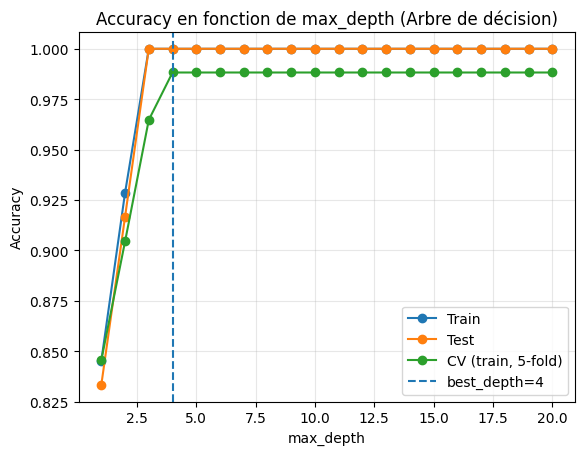


📌 Accuracy finale (test): 1.0
📌 Profondeur réelle de l'arbre: 3
📌 Nombre de feuilles: 4


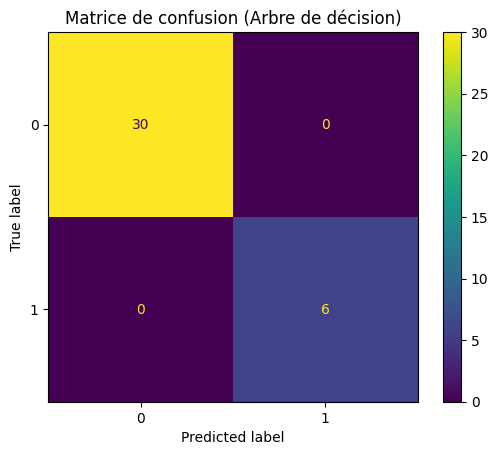


📌 Classification report :

              precision    recall  f1-score   support

       Echec       1.00      1.00      1.00        30
    Reussite       1.00      1.00      1.00         6

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



<Figure size 640x480 with 0 Axes>

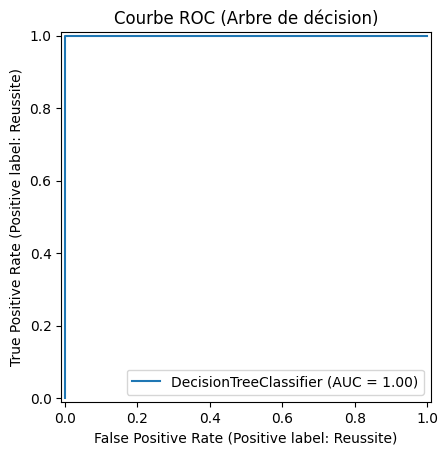

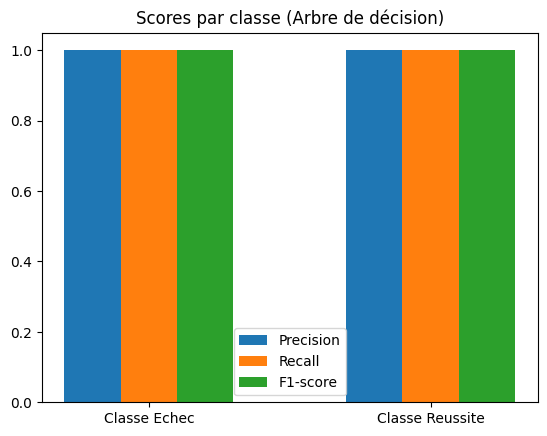

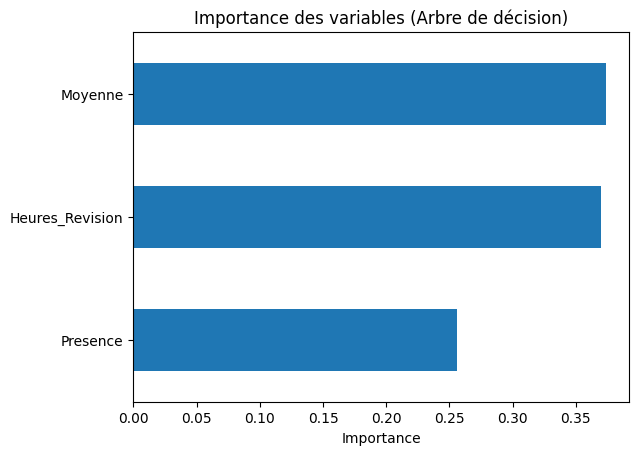

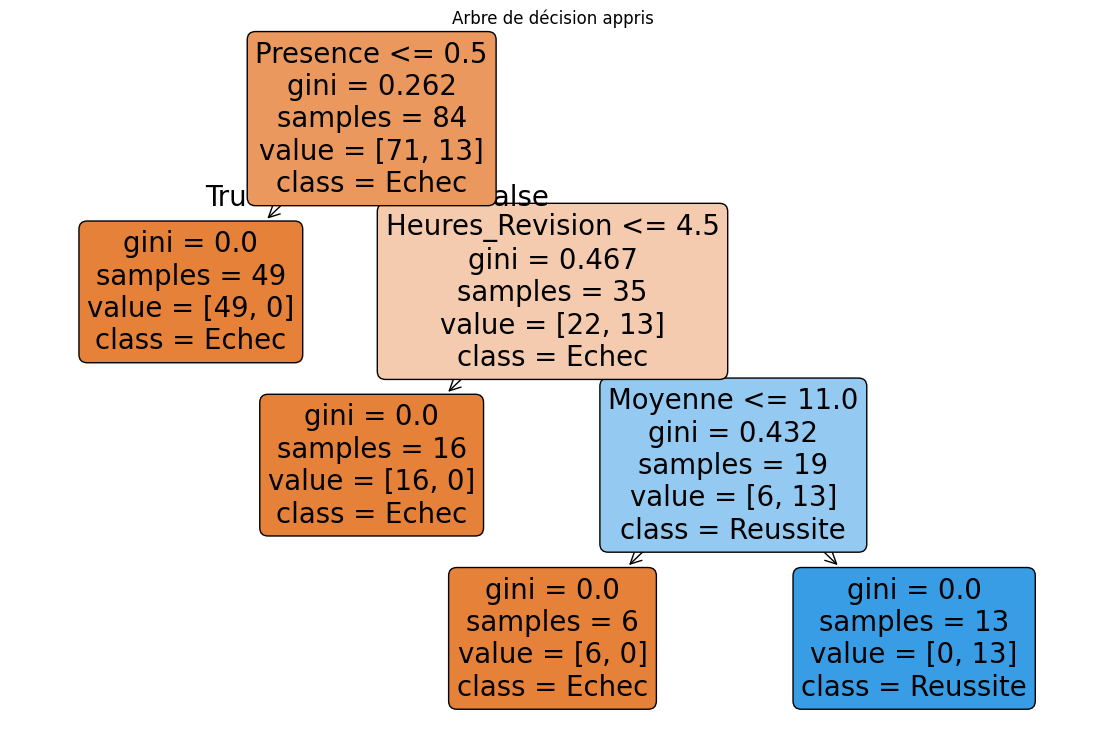

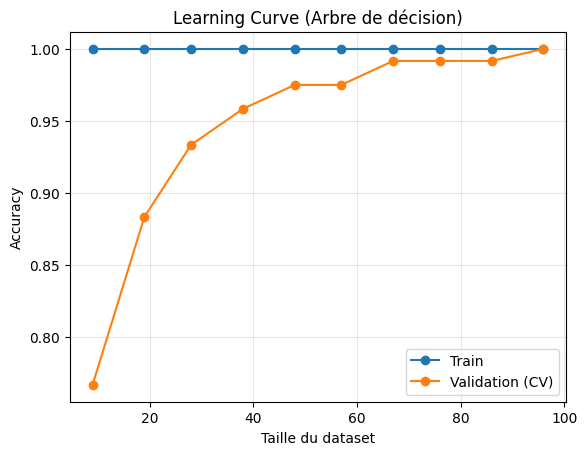

In [ ]:
# =========================
# MINI-PROJET 2 — Arbre de Décision (Réussite Étudiants)
# Code complet : choix de max_depth + entraînement + évaluation + plots + affichage de l'arbre
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, RocCurveDisplay, precision_recall_fscore_support
)

# =========================
# 1) Chargement des données
# =========================
data = pd.read_csv("mini_projet_2_etudiants.csv")

# Séparation X / y
X = data.drop("Resultat", axis=1)
y = data["Resultat"]

# Split train/test (stratify pour garder les proportions de classes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# =========================
# 2) Choix de la profondeur (max_depth) : approche "scientifique"
#    -> on teste plusieurs profondeurs et on observe train vs test + CV
# =========================
depths = range(1, 21)

train_acc = []
test_acc = []
cv_acc = []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)

    # Accuracy sur train et test
    train_acc.append(clf.score(X_train, y_train))
    test_acc.append(clf.score(X_test, y_test))

    # Accuracy moyenne en validation croisée (plus robuste)
    cv_acc.append(cross_val_score(clf, X_train, y_train, cv=5).mean())

# Meilleure profondeur selon la validation croisée (recommandé)
best_depth = list(depths)[int(np.argmax(cv_acc))]
print(f"✅ Meilleur max_depth (selon CV) = {best_depth} | CV Accuracy = {max(cv_acc):.4f}")

# Plot : train/test accuracy vs depth
plt.figure()
plt.plot(list(depths), train_acc, marker="o", label="Train")
plt.plot(list(depths), test_acc, marker="o", label="Test")
plt.plot(list(depths), cv_acc, marker="o", label="CV (train, 5-fold)")
plt.axvline(best_depth, linestyle="--", label=f"best_depth={best_depth}")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Accuracy en fonction de max_depth (Arbre de décision)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# =========================
# 3) Modèle final avec best_depth
# =========================
model = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("\n📌 Accuracy finale (test):", accuracy_score(y_test, y_pred))
print("📌 Profondeur réelle de l'arbre:", model.get_depth())
print("📌 Nombre de feuilles:", model.get_n_leaves())

# =========================
# 4) Matrice de confusion
# =========================
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Matrice de confusion (Arbre de décision)")
plt.show()

# =========================
# 5) Classification report
# =========================
print("\n📌 Classification report :\n")
print(classification_report(y_test, y_pred))

# =========================
# 6) ROC Curve (si classification binaire 0/1)
# =========================
# Si y est binaire, DecisionTreeClassifier supporte predict_proba => ROC possible
try:
    plt.figure()
    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title("Courbe ROC (Arbre de décision)")
    plt.show()
except Exception as e:
    print("⚠️ ROC non disponible (probablement multi-classes). Détail:", e)

# =========================
# 7) Plot scores par classe : Precision / Recall / F1
# =========================
labels = sorted(y.unique())
prec, rec, f1, sup = precision_recall_fscore_support(y_test, y_pred, labels=labels, zero_division=0)

plt.figure()
x = np.arange(len(labels))
plt.bar(x - 0.2, prec, width=0.2, label="Precision")
plt.bar(x,       rec,  width=0.2, label="Recall")
plt.bar(x + 0.2, f1,   width=0.2, label="F1-score")
plt.xticks(x, [f"Classe {lab}" for lab in labels])
plt.ylim(0, 1.05)
plt.title("Scores par classe (Arbre de décision)")
plt.legend()
plt.show()

# =========================
# 8) Importance des variables
# =========================
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values()
plt.figure()
importances.plot(kind="barh")
plt.title("Importance des variables (Arbre de décision)")
plt.xlabel("Importance")
plt.show()

# =========================
# 9) Visualisation de l'arbre
# =========================
plt.figure(figsize=(14, 9))
plot_tree(
    model,
    feature_names=list(X.columns),
    class_names=[str(c) for c in labels],
    filled=True,
    rounded=True
)
plt.title("Arbre de décision appris")
plt.show()

# =========================
# 10) Learning Curve (option très pédagogique)
# =========================
# Permet de voir surapprentissage / sous-apprentissage selon la taille de données
train_sizes, train_scores, val_scores = learning_curve(
    DecisionTreeClassifier(max_depth=best_depth, random_state=42),
    X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 10)
)

plt.figure()
plt.plot(train_sizes, train_scores.mean(axis=1), marker="o", label="Train")
plt.plot(train_sizes, val_scores.mean(axis=1), marker="o", label="Validation (CV)")
plt.xlabel("Taille du dataset")
plt.ylabel("Accuracy")
plt.title("Learning Curve (Arbre de décision)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 📧 Mini-Projet 3 — Naive Bayes : Spam Email



Aperçu du dataset :
      Label                                              Email
0  non_spam  Go until jurong point, crazy.. Available only ...
1  non_spam                      Ok lar... Joking wif u oni...
2      spam  Free entry in 2 a wkly comp to win FA Cup fina...
3  non_spam  U dun say so early hor... U c already then say...
4  non_spam  Nah I don't think he goes to usf, he lives aro...

Dimensions : (5572, 2)

Exemples de labels bruts : <StringArray>
['non_spam', 'spam']
Length: 2, dtype: str
Labels uniques après nettoyage : [0, 1]


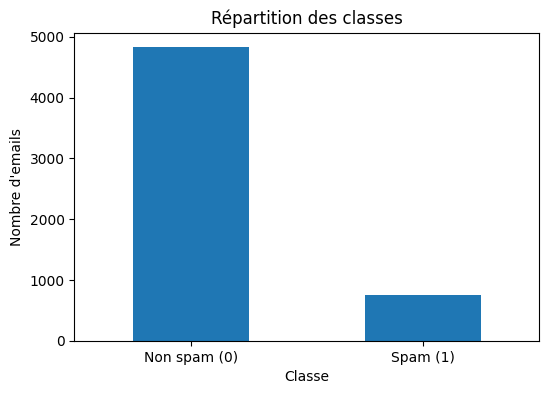

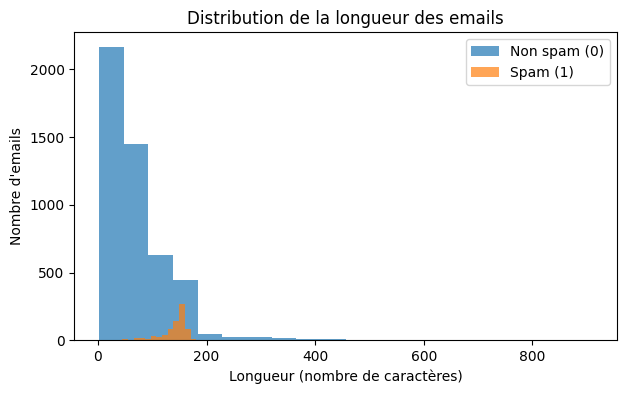

Taille de la matrice X : (5572, 8444) (emails x mots)

Accuracy Naive Bayes : 0.9815


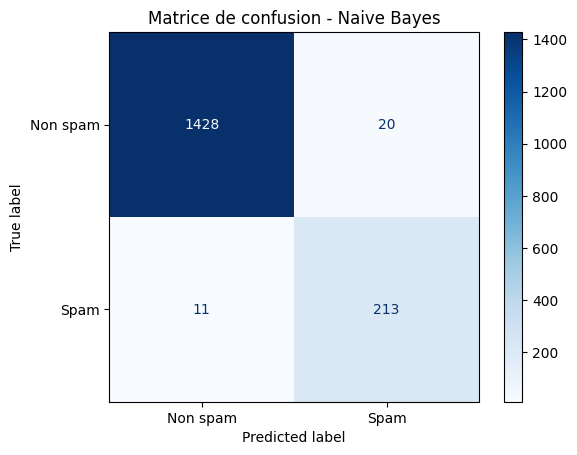


Classification report :

              precision    recall  f1-score   support

    Non spam       0.99      0.99      0.99      1448
        Spam       0.91      0.95      0.93       224

    accuracy                           0.98      1672
   macro avg       0.95      0.97      0.96      1672
weighted avg       0.98      0.98      0.98      1672



<Figure size 600x500 with 0 Axes>

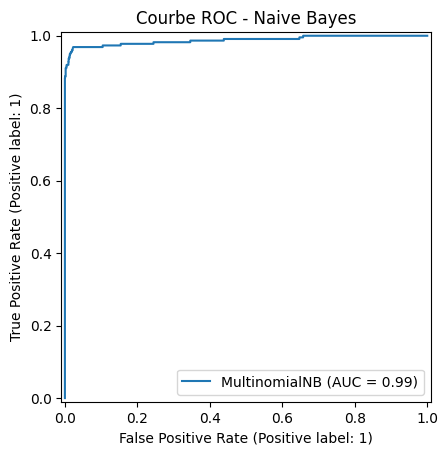

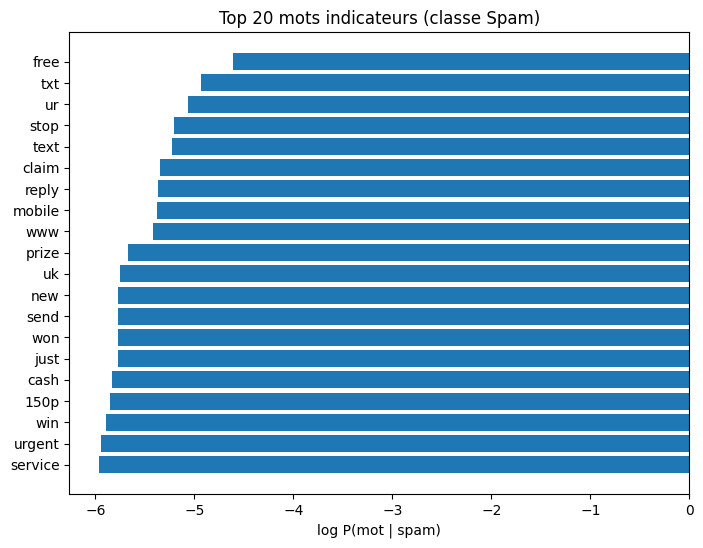

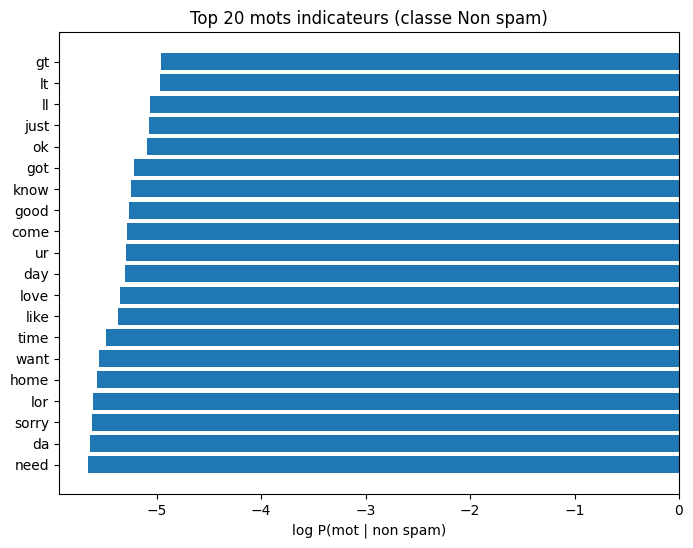

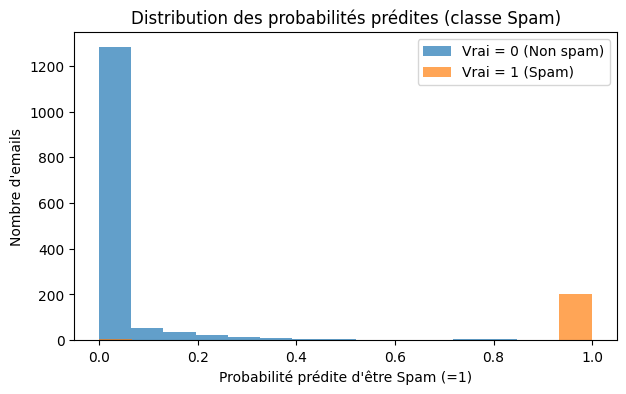

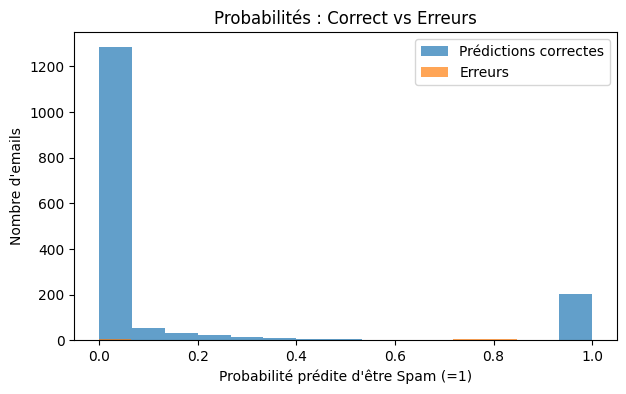

In [ ]:
# =========================
# MINI-PROJET 3 — Naive Bayes : Spam Email
# Code complet + figures utiles
# Objectif : construire un modèle capable de classifier
# un email comme SPAM ou NON-SPAM
# =========================


# =========================
# Importation des bibliothèques
# =========================

import pandas as pd        # pandas : manipulation de données sous forme de DataFrame (tableaux)
import numpy as np         # numpy : calcul scientifique et manipulation de matrices
import matplotlib.pyplot as plt  # matplotlib : création de graphiques

# fonctions pour séparer les données en train et test
from sklearn.model_selection import train_test_split

# outil qui transforme le texte en variables numériques
from sklearn.feature_extraction.text import CountVectorizer

# algorithme de classification Naive Bayes
from sklearn.naive_bayes import MultinomialNB

# métriques pour évaluer les performances du modèle
from sklearn.metrics import (
    accuracy_score,           # calcule la précision globale
    confusion_matrix,         # calcule la matrice de confusion
    ConfusionMatrixDisplay,   # affichage graphique de la matrice
    classification_report,    # rapport détaillé des métriques
    RocCurveDisplay           # affichage de la courbe ROC
)


# =========================
# 1) Chargement du dataset
# =========================

# URL du dataset SMS Spam Collection
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

# Lecture du dataset directement depuis internet
# sep="\t" indique que les colonnes sont séparées par une tabulation
# names=["Label","Email"] définit les noms des colonnes
data = pd.read_csv(url, sep="\t", names=["Label", "Email"])


# Conversion des labels pour harmoniser les données
# ham = email normal
# spam = email indésirable
data["Label"] = data["Label"].replace({
    "ham": "non_spam",
    "spam": "spam"
})


# Sauvegarde locale optionnelle
# permet d'enregistrer le dataset localement
# data.to_csv("mini_projet_3_spam.csv", index=False)


# Affichage des premières lignes pour vérifier les données
print("Aperçu du dataset :")
print(data.head())

# Affichage des dimensions du dataset (nombre de lignes, colonnes)
print("\nDimensions :", data.shape)


# Vérification que les colonnes nécessaires existent
if "Email" not in data.columns or "Label" not in data.columns:
    raise ValueError("Le fichier doit contenir les colonnes 'Email' et 'Label'.")


# X_text : contient les emails (variables explicatives)
X_text = data["Email"].astype(str)

# y_raw : labels bruts (spam ou non spam)
y_raw = data["Label"]

print("\nExemples de labels bruts :", y_raw.unique()[:10])


# =========================
# 2) Nettoyage robuste des labels
# =========================

# Uniformiser les labels
# astype(str) convertit en texte
# strip() enlève les espaces
# lower() transforme en minuscules
y_clean = y_raw.astype(str).str.strip().str.lower()


# Dictionnaire de conversion texte -> numérique
# 1 = spam
# 0 = non spam
mapping = {
    "spam": 1, "spams": 1, "1": 1, "true": 1, "yes": 1, "y": 1,
    "non_spam": 0, "non spam": 0, "nonspam": 0, "ham": 0, "not spam": 0,
    "0": 0, "false": 0, "no": 0, "n": 0
}


# Application du mapping aux labels
y_mapped = y_clean.map(mapping)


# Vérification des labels inconnus
if y_mapped.isna().any():
    unknown = sorted(y_clean[y_mapped.isna()].unique().tolist())
    raise ValueError(f"Labels inconnus dans 'Label' : {unknown}")


# Conversion finale en entier
y = y_mapped.astype(int)

print("Labels uniques après nettoyage :", sorted(y.unique().tolist()))


# =========================
# FIGURE A) Répartition des classes
# =========================

# Visualisation du nombre de spam vs non spam
plt.figure(figsize=(6, 4))

# value_counts() compte le nombre d'emails dans chaque classe
# sort_index() ordonne les classes (0 puis 1)
y.value_counts().sort_index().plot(kind="bar")

plt.xticks([0, 1], ["Non spam (0)", "Spam (1)"], rotation=0)

plt.title("Répartition des classes")
plt.xlabel("Classe")
plt.ylabel("Nombre d'emails")

plt.show()


# =========================
# FIGURE B) Longueur des emails par label
# =========================

# Calcul de la longueur de chaque email
email_len = X_text.str.len()

plt.figure(figsize=(7, 4))

# Histogramme pour les emails non spam
plt.hist(email_len[y == 0], bins=20, alpha=0.7, label="Non spam (0)")

# Histogramme pour les emails spam
plt.hist(email_len[y == 1], bins=20, alpha=0.7, label="Spam (1)")

plt.title("Distribution de la longueur des emails")
plt.xlabel("Longueur (nombre de caractères)")
plt.ylabel("Nombre d'emails")

plt.legend()

plt.show()


# =========================
# 3) Vectorisation texte -> nombres
# =========================

# CountVectorizer transforme le texte en matrice de mots
# stop_words="english" supprime les mots fréquents (the, is, and...)
vectorizer = CountVectorizer(stop_words="english")

# fit_transform :
# - fit apprend le vocabulaire
# - transform transforme les emails en matrice numérique
X = vectorizer.fit_transform(X_text)

print("Taille de la matrice X :", X.shape, "(emails x mots)")


# =========================
# 4) Train / Test split
# =========================

# division du dataset en deux parties :
# 70% pour l'entraînement
# 30% pour le test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,      # proportion des données utilisées pour le test
    random_state=42,    # graine aléatoire pour reproductibilité
    stratify=y          # conserve la proportion spam/non spam
)


# =========================
# 5) Modèle Naive Bayes
# =========================

# MultinomialNB : algorithme de classification probabiliste
model = MultinomialNB()

# entraînement du modèle
model.fit(X_train, y_train)


# prédiction sur les données test
y_pred = model.predict(X_test)

# calcul de la précision
acc = accuracy_score(y_test, y_pred)

print("\nAccuracy Naive Bayes :", round(acc, 4))


# =========================
# FIGURE C) Matrice de confusion
# =========================

# comparaison entre vraies classes et classes prédites
cm = confusion_matrix(y_test, y_pred)

# affichage graphique
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non spam", "Spam"]
)

disp.plot(cmap="Blues")

plt.title("Matrice de confusion - Naive Bayes")

plt.show()


# =========================
# Rapport détaillé
# =========================

print("\nClassification report :\n")

# affiche precision, recall et F1-score
print(classification_report(
    y_test,
    y_pred,
    target_names=["Non spam", "Spam"]
))


# =========================
# FIGURE D) Courbe ROC
# =========================

plt.figure(figsize=(6, 5))

# ROC compare TPR (True Positive Rate) et FPR (False Positive Rate)
RocCurveDisplay.from_estimator(model, X_test, y_test)

plt.title("Courbe ROC - Naive Bayes")

plt.show()


# =========================
# FIGURE E) Top mots indicateurs SPAM
# =========================

# récupération du vocabulaire
feature_names = np.array(vectorizer.get_feature_names_out())

# probabilité des mots pour la classe spam
log_prob_spam = model.feature_log_prob_[1]

# sélection des 20 mots les plus caractéristiques
top_spam_idx = np.argsort(log_prob_spam)[-20:]
top_spam_idx = top_spam_idx[np.argsort(log_prob_spam[top_spam_idx])]

plt.figure(figsize=(8, 6))

plt.barh(feature_names[top_spam_idx], log_prob_spam[top_spam_idx])

plt.title("Top 20 mots indicateurs (classe Spam)")
plt.xlabel("log P(mot | spam)")

plt.show()


# =========================
# FIGURE F) Top mots indicateurs NON-SPAM
# =========================

log_prob_ham = model.feature_log_prob_[0]

top_ham_idx = np.argsort(log_prob_ham)[-20:]
top_ham_idx = top_ham_idx[np.argsort(log_prob_ham[top_ham_idx])]

plt.figure(figsize=(8, 6))

plt.barh(feature_names[top_ham_idx], log_prob_ham[top_ham_idx])

plt.title("Top 20 mots indicateurs (classe Non spam)")
plt.xlabel("log P(mot | non spam)")

plt.show()


# =========================
# FIGURE G) Histogramme des probabilités
# =========================

# probabilité prédite d'être spam
y_proba_spam = model.predict_proba(X_test)[:, 1]

plt.figure(figsize=(7, 4))

plt.hist(y_proba_spam[y_test == 0], bins=15, alpha=0.7, label="Vrai = 0 (Non spam)")
plt.hist(y_proba_spam[y_test == 1], bins=15, alpha=0.7, label="Vrai = 1 (Spam)")

plt.title("Distribution des probabilités prédites (classe Spam)")
plt.xlabel("Probabilité prédite d'être Spam (=1)")
plt.ylabel("Nombre d'emails")

plt.legend()

plt.show()


# =========================
# FIGURE H) Analyse des erreurs
# =========================

# identification des erreurs de classification
errors = (y_pred != y_test)

plt.figure(figsize=(7, 4))

plt.hist(y_proba_spam[~errors], bins=15, alpha=0.7, label="Prédictions correctes")
plt.hist(y_proba_spam[errors], bins=15, alpha=0.7, label="Erreurs")

plt.title("Probabilités : Correct vs Erreurs")
plt.xlabel("Probabilité prédite d'être Spam (=1)")
plt.ylabel("Nombre d'emails")

plt.legend()

plt.show()

# 🧮 Mini-Projet 4 — SVM non linéaire COMPLET : Classification Fruits
### Contexte

On dispose d’un dataset contenant des caractéristiques physiques de fruits :

* **Poids**
* **Diamètre**

Chaque fruit appartient à une classe :

* **Pomme**
* **Orange**
### Travail demandé

#### 1️⃣ Création ou chargement du dataset

Créer un dataset contenant :

| Poids | Diamètre | Type   |
| ----- | -------- | ------ |
| 100   | 5        | Pomme  |
| 120   | 6        | Pomme  |
| 200   | 10       | Orange |
| 220   | 11       | Orange |

Séparer :

* **X : variables explicatives**
* **y : variable cible**

---

#### 2️⃣ Standardisation

Appliquer une **standardisation** avec `StandardScaler`.

Expliquer pourquoi cette étape est importante pour **SVM**.

---

#### 3️⃣ Entraînement du modèle



#### 4️⃣ Prédiction



#### 5️⃣ Visualisation




Classes : <StringArray>
['Orange', 'Pomme']
Length: 2, dtype: str


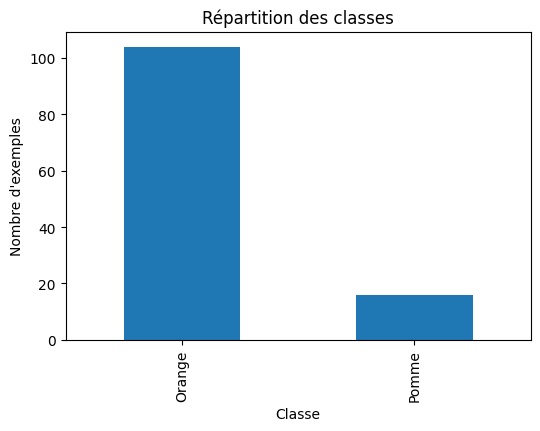

Classes encodées : {'Orange': np.int64(0), 'Pomme': np.int64(1)}
Taille X_train : (84, 2)
Taille X_test  : (36, 2)
Meilleurs paramètres : {'C': 1, 'gamma': 1, 'kernel': 'rbf'}

Accuracy SVM : 1.0

Classification report :

              precision    recall  f1-score   support

      Orange       1.00      1.00      1.00        31
       Pomme       1.00      1.00      1.00         5

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



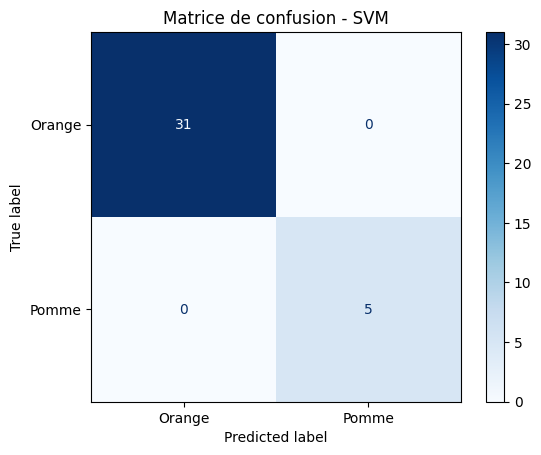

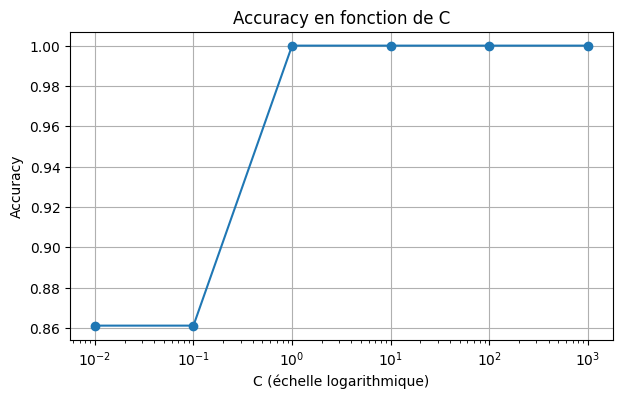

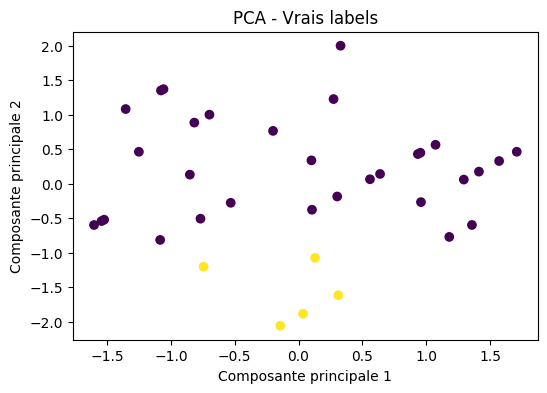

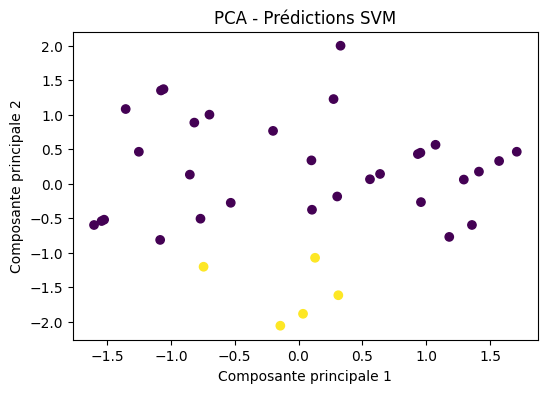

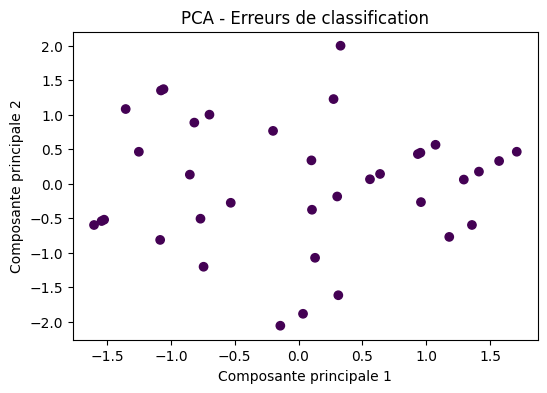

<Figure size 600x500 with 0 Axes>

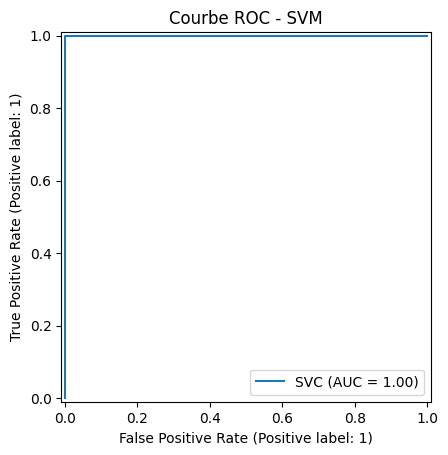

<Figure size 600x500 with 0 Axes>

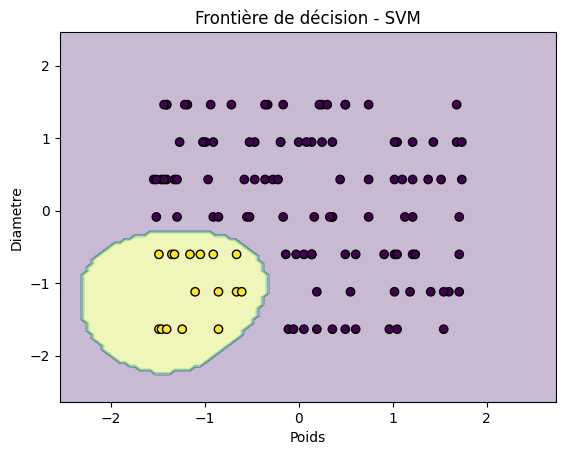


Résumé final :
Meilleur modèle : SVC(C=1, gamma=1, probability=True)
Accuracy finale : 1.0


In [ ]:
# ============================================================
# MINI-PROJET 4 — SVM NON LINÉAIRE COMPLET
# Classification de fruits avec SVM (kernel RBF)
# ============================================================

# =========================
# 0) Importation des bibliothèques
# =========================

import pandas as pd
# pandas : bibliothèque utilisée pour lire et manipuler des tableaux de données (DataFrame)

import numpy as np
# numpy : bibliothèque de calcul numérique et de manipulation de tableaux/matrices

import matplotlib.pyplot as plt
# matplotlib.pyplot : bibliothèque pour créer des graphiques


# train_test_split :
# sépare les données en deux parties :
# - données d'entraînement (train)
# - données de test (test)

# GridSearchCV :
# teste automatiquement plusieurs combinaisons d’hyperparamètres
# pour trouver le meilleur modèle
from sklearn.model_selection import train_test_split, GridSearchCV


# StandardScaler :
# standardise les variables numériques
# transforme chaque variable pour avoir :
# - moyenne = 0
# - écart-type = 1

# LabelEncoder :
# transforme des labels texte en nombres
# exemple : "Pomme" -> 0, "Orange" -> 1
from sklearn.preprocessing import StandardScaler, LabelEncoder


# SVC :
# Support Vector Classifier
# modèle de classification basé sur les vecteurs de support
from sklearn.svm import SVC


# accuracy_score :
# calcule la proportion de bonnes prédictions

# confusion_matrix :
# compare les vraies classes et les classes prédites

# ConfusionMatrixDisplay :
# affiche la matrice de confusion sous forme graphique

# classification_report :
# affiche precision, recall, f1-score et support

# RocCurveDisplay :
# affiche la courbe ROC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    RocCurveDisplay
)


# PCA :
# réduction de dimension
# permet de projeter les données en 2 dimensions pour les visualiser
from sklearn.decomposition import PCA


# DecisionBoundaryDisplay :
# affiche graphiquement la frontière de décision du modèle
from sklearn.inspection import DecisionBoundaryDisplay


# =========================
# 1) Chargement du dataset
# =========================

# read_csv() :
# lit un fichier CSV
# ici on charge le dataset des fruits
data = pd.read_csv("mini_projet_4_fruits.csv")

# X :
# variables explicatives = toutes les colonnes sauf la cible "Type"
X = data.drop("Type", axis=1)

# drop("Type", axis=1) :
# supprime la colonne "Type"
# axis=1 signifie qu’on supprime une colonne et non une ligne

# y :
# variable cible = la colonne à prédire
y = data["Type"]

# y.unique() :
# affiche les classes présentes dans la variable cible
print("Classes :", y.unique())


# =========================
# A) Répartition des classes
# =========================

plt.figure(figsize=(6, 4))
# figure(figsize=(6,4)) :
# crée une figure de largeur 6 et hauteur 4

y.value_counts().plot(kind="bar")
# value_counts() :
# compte le nombre d'exemples dans chaque classe
# plot(kind="bar") :
# affiche un diagramme en barres

plt.title("Répartition des classes")
# title() : titre du graphique

plt.xlabel("Classe")
# xlabel() : nom de l’axe horizontal

plt.ylabel("Nombre d'exemples")
# ylabel() : nom de l’axe vertical

plt.show()
# show() : affiche la figure


# =========================
# 2) Encodage des labels
# =========================

le = LabelEncoder()
# création de l’encodeur de labels

y_encoded = le.fit_transform(y)
# fit_transform() :
# - fit : apprend la correspondance entre texte et nombres
# - transform : applique cette correspondance
# exemple : Pomme -> 0, Orange -> 1

print("Classes encodées :", dict(zip(le.classes_, le.transform(le.classes_))))
# zip(...) : associe chaque classe à son code numérique


# =========================
# 3) Standardisation des variables
# =========================

scaler = StandardScaler()
# création du standardiseur

X_scaled = scaler.fit_transform(X)
# fit_transform() :
# - fit : calcule moyenne et écart-type de chaque variable
# - transform : applique la standardisation

# Pourquoi standardiser ?
# Parce que SVM dépend des distances entre les points.
# Si une variable a des valeurs beaucoup plus grandes qu’une autre,
# elle peut dominer le modèle.


# =========================
# 4) Séparation Train / Test
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,         # données d’entrée standardisées
    y_encoded,        # labels encodés
    test_size=0.3,    # 30% des données pour le test
    random_state=42,  # fixe l’aléatoire pour avoir toujours le même découpage
    stratify=y_encoded
    # stratify :
    # garde la même proportion des classes dans train et test
)

print("Taille X_train :", X_train.shape)
print("Taille X_test  :", X_test.shape)


# =========================
# 5) Recherche des meilleurs hyperparamètres
# =========================

# param_grid :
# dictionnaire contenant les paramètres à tester

# C :
# contrôle le compromis entre :
# - grande marge
# - faible nombre d’erreurs de classification
# petit C  -> plus tolérant aux erreurs
# grand C  -> moins tolérant aux erreurs

# gamma :
# contrôle l’influence d’un point dans le noyau RBF
# petit gamma -> frontière plus lisse
# grand gamma -> frontière plus complexe

# kernel="rbf" :
# noyau non linéaire
# permet de séparer des classes qui ne sont pas séparables par une simple droite
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": [0.01, 0.1, 1],
    "kernel": ["rbf"]
}

# GridSearchCV :
# teste toutes les combinaisons du param_grid
# et choisit celle qui donne la meilleure performance en validation croisée

# SVC(probability=True) :
# probability=True permet d’obtenir les probabilités nécessaires
# pour tracer la courbe ROC plus tard

# cv=5 :
# validation croisée en 5 sous-ensembles
grid = GridSearchCV(
    SVC(probability=True),
    param_grid,
    cv=5
)

# fit() :
# entraîne tous les modèles testés sur les données d'entraînement
grid.fit(X_train, y_train)

# best_params_ :
# renvoie la meilleure combinaison trouvée
print("Meilleurs paramètres :", grid.best_params_)

# best_estimator_ :
# renvoie le meilleur modèle final
best_model = grid.best_estimator_


# =========================
# 6) Prédictions du modèle final
# =========================

y_pred = best_model.predict(X_test)
# predict() :
# prédit la classe des observations du jeu de test

acc = accuracy_score(y_test, y_pred)
# accuracy_score(y_test, y_pred) :
# compare les vraies classes et les classes prédites
# puis calcule la proportion de bonnes prédictions

print("\nAccuracy SVM :", round(acc, 4))

print("\nClassification report :\n")
print(classification_report(
    y_test,                # vraies classes
    y_pred,                # classes prédites
    target_names=le.classes_
    # target_names :
    # noms des classes affichés dans le rapport
))


# =========================
# B) Matrice de confusion
# =========================

cm = confusion_matrix(y_test, y_pred)
# confusion_matrix() :
# construit une matrice qui compare :
# - les vraies classes
# - les classes prédites

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)
# display_labels :
# noms affichés sur les axes

disp.plot(cmap="Blues")
# plot(cmap="Blues") :
# affiche la matrice avec une palette de couleur bleue

plt.title("Matrice de confusion - SVM")
plt.show()


# =========================
# C) Courbe Accuracy en fonction de C
# =========================

C_values = [0.01, 0.1, 1, 10, 100, 1000]
# différentes valeurs de C à tester

accuracies = []
# liste vide pour stocker les accuracies

for C in C_values:
    model = SVC(
        kernel="rbf",     # noyau non linéaire
        C=C,              # valeur actuelle du paramètre C
        gamma="scale",    # gamma calculé automatiquement par sklearn
        probability=True  # nécessaire pour certaines métriques probabilistes
    )

    model.fit(X_train, y_train)
    # entraînement du modèle

    acc = model.score(X_test, y_test)
    # score() :
    # calcule directement l'accuracy sur le jeu de test

    accuracies.append(acc)
    # ajoute l’accuracy à la liste

plt.figure(figsize=(7, 4))

plt.plot(C_values, accuracies, marker="o")
# plot() :
# trace la courbe accuracy en fonction de C
# marker="o" :
# affiche des points ronds sur la courbe

plt.xscale("log")
# xscale("log") :
# met l’axe X en échelle logarithmique

plt.xlabel("C (échelle logarithmique)")
plt.ylabel("Accuracy")
plt.title("Accuracy en fonction de C")
plt.grid(True)
plt.show()


# =========================
# D) Visualisation PCA
# =========================

pca = PCA(n_components=2)
# n_components=2 :
# on réduit les données à 2 dimensions

X_test_2d = pca.fit_transform(X_test)
# fit_transform() :
# apprend la projection PCA puis transforme X_test en 2 dimensions

# --- Graphique des vraies classes
plt.figure(figsize=(6, 4))
plt.scatter(
    X_test_2d[:, 0],   # 1ère composante principale
    X_test_2d[:, 1],   # 2ème composante principale
    c=y_test           # couleur selon la vraie classe
)
plt.title("PCA - Vrais labels")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.show()

# --- Graphique des prédictions
plt.figure(figsize=(6, 4))
plt.scatter(
    X_test_2d[:, 0],
    X_test_2d[:, 1],
    c=y_pred           # couleur selon la classe prédite
)
plt.title("PCA - Prédictions SVM")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.show()

# --- Graphique des erreurs
errors = (y_pred != y_test)
# errors :
# tableau booléen
# True si la prédiction est fausse
# False si la prédiction est correcte

plt.figure(figsize=(6, 4))
plt.scatter(
    X_test_2d[:, 0],
    X_test_2d[:, 1],
    c=errors.astype(int)
    # astype(int) :
    # False -> 0
    # True  -> 1
)
plt.title("PCA - Erreurs de classification")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.show()


# =========================
# E) Courbe ROC (si classification binaire)
# =========================

# la ROC s’utilise directement surtout pour 2 classes
if len(le.classes_) == 2:
    plt.figure(figsize=(6, 5))

    RocCurveDisplay.from_estimator(
        best_model,  # le même modèle final que celui utilisé partout
        X_test,      # données de test
        y_test       # vraies classes
    )

    plt.title("Courbe ROC - SVM")
    plt.show()


# =========================
# F) Frontière de décision (si 2 variables)
# =========================

# on ne peut afficher directement la frontière de décision
# que si le dataset contient exactement 2 variables explicatives
if X.shape[1] == 2:
    plt.figure(figsize=(6, 5))

    DecisionBoundaryDisplay.from_estimator(
        best_model,            # modèle utilisé
        X_scaled,              # données à afficher
        response_method="predict",
        # response_method="predict" :
        # la couleur de chaque zone dépend de la classe prédite
        alpha=0.3
        # alpha :
        # transparence de la zone colorée
    )

    plt.scatter(
        X_scaled[:, 0],        # variable 1
        X_scaled[:, 1],        # variable 2
        c=y_encoded,           # couleur selon la vraie classe
        edgecolor="k"          # contour noir autour des points
    )

    plt.title("Frontière de décision - SVM")
    plt.xlabel(X.columns[0])
    plt.ylabel(X.columns[1])
    plt.show()
else:
    print("Frontière non affichée : nécessite exactement 2 variables.")


# =========================
# G) Résumé final
# =========================

print("\nRésumé final :")
print("Meilleur modèle :", best_model)
print("Accuracy finale :", round(acc, 4))

# MINI-PROJET 4 — SVM LINÉAIRE COMPLET: : Classification Fruits

Classes présentes : <StringArray>
['Orange', 'Pomme']
Length: 2, dtype: str


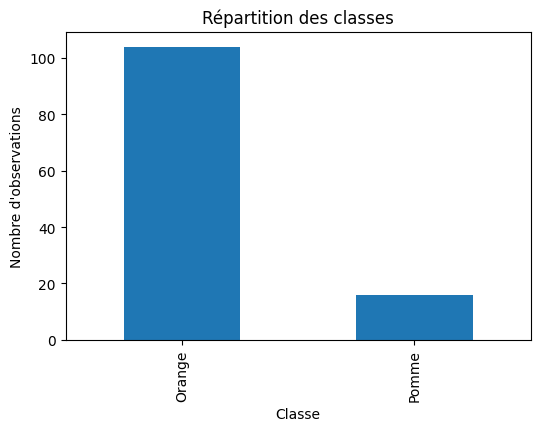

Encodage des classes : {'Orange': np.int64(0), 'Pomme': np.int64(1)}
Taille X_train : (84, 2)
Taille X_test : (36, 2)
Meilleurs paramètres : {'C': 10, 'kernel': 'linear'}

Accuracy du SVM linéaire : 1.0

Classification report :
              precision    recall  f1-score   support

      Orange       1.00      1.00      1.00        31
       Pomme       1.00      1.00      1.00         5

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



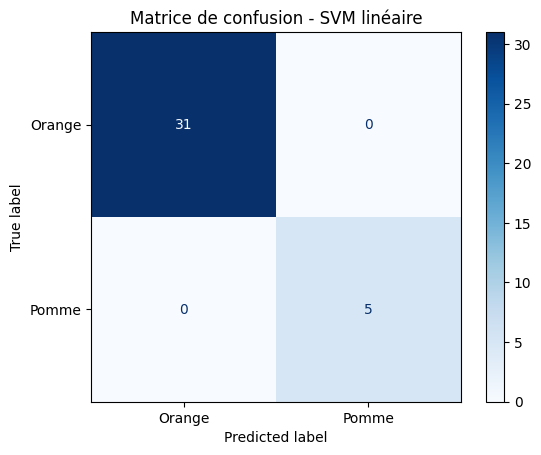

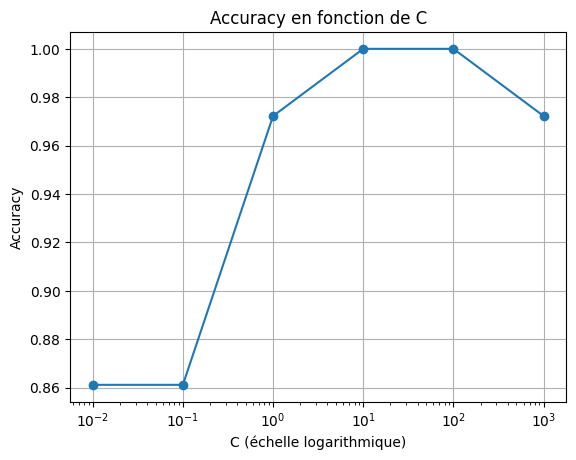

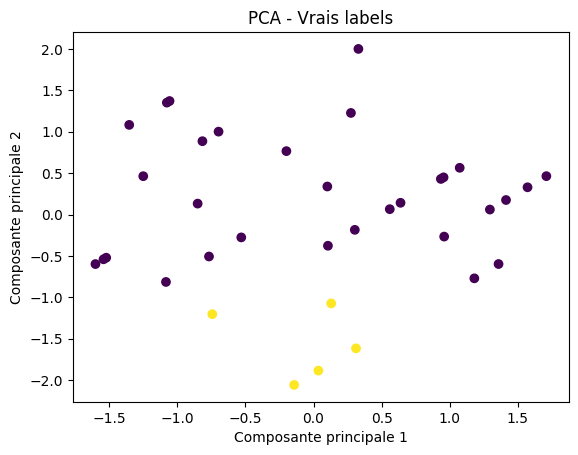

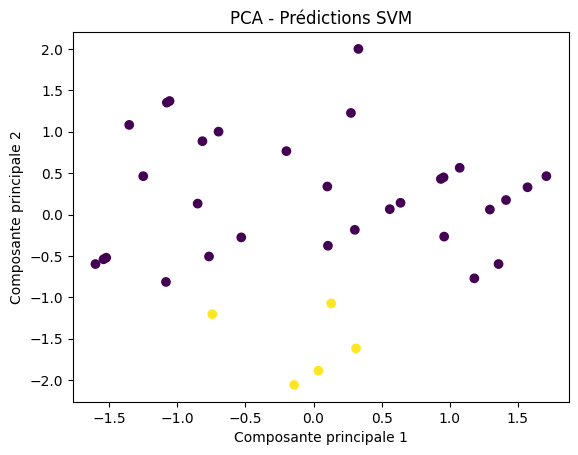

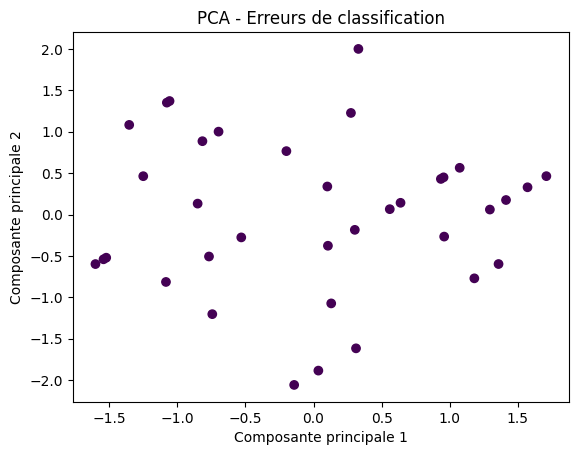

<Figure size 640x480 with 0 Axes>

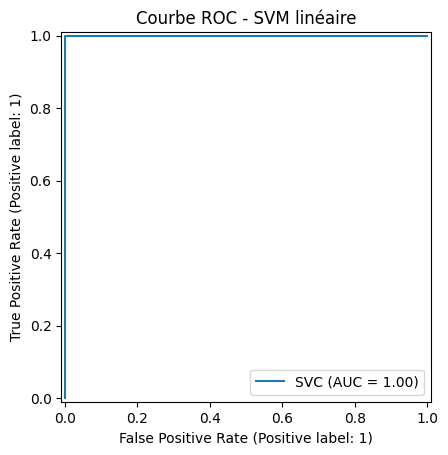

<Figure size 640x480 with 0 Axes>

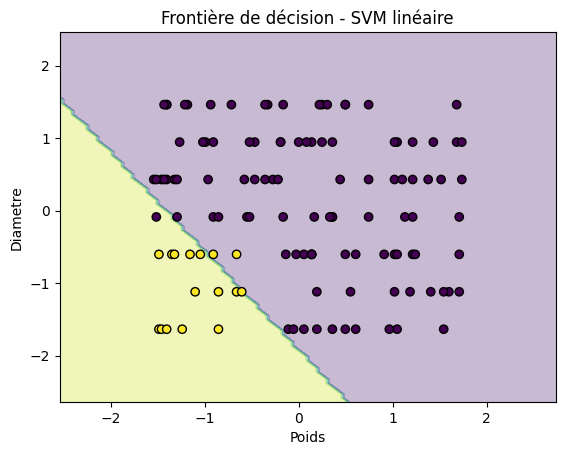

In [ ]:
# ============================================================
# MINI-PROJET 4 — SVM LINEAIRE COMPLET
# Classification de fruits avec SVM (Support Vector Machine)
# ============================================================


# =========================
# 0) Importation des bibliothèques
# =========================

import pandas as pd
# pandas : bibliothèque utilisée pour lire et manipuler des tableaux de données (DataFrame)

import numpy as np
# numpy : bibliothèque de calcul scientifique et manipulation de matrices

import matplotlib.pyplot as plt
# matplotlib.pyplot : bibliothèque utilisée pour créer des graphiques


# train_test_split :
# fonction qui sépare le dataset en deux parties :
# - données d'entraînement
# - données de test

# GridSearchCV :
# teste automatiquement plusieurs combinaisons de paramètres
# pour trouver le modèle optimal
from sklearn.model_selection import train_test_split, GridSearchCV


# StandardScaler :
# met toutes les variables sur la même échelle
# moyenne = 0
# écart-type = 1

# LabelEncoder :
# transforme les classes texte en valeurs numériques
# exemple : "Pomme" → 0, "Orange" → 1
from sklearn.preprocessing import StandardScaler, LabelEncoder


# SVC :
# Support Vector Classifier
# modèle de classification basé sur les vecteurs de support
from sklearn.svm import SVC


# accuracy_score :
# mesure le pourcentage de prédictions correctes

# confusion_matrix :
# compare les vraies classes et les classes prédites

# ConfusionMatrixDisplay :
# affiche la matrice de confusion sous forme graphique

# classification_report :
# affiche precision, recall et f1-score

# RocCurveDisplay :
# affiche la courbe ROC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    RocCurveDisplay
)


# PCA :
# réduction de dimension
# permet de projeter les données dans un espace 2D pour visualisation
from sklearn.decomposition import PCA


# DecisionBoundaryDisplay :
# permet de visualiser la frontière de décision du modèle
from sklearn.inspection import DecisionBoundaryDisplay


# ============================================================
# 1) Chargement du dataset
# ============================================================

# lecture du fichier CSV contenant les données
data = pd.read_csv("mini_projet_4_fruits.csv")

# X : variables explicatives (features)
# toutes les colonnes sauf la variable cible
X = data.drop("Type", axis=1)

# drop("Type", axis=1)
# axis=1 signifie qu'on supprime une colonne

# y : variable cible à prédire
y = data["Type"]

# afficher les différentes classes présentes
print("Classes présentes :", y.unique())


# ============================================================
# A) Répartition des classes
# ============================================================

plt.figure(figsize=(6,4))

# value_counts() :
# compte le nombre d'exemples dans chaque classe

# plot(kind="bar") :
# affiche un diagramme en barres
y.value_counts().plot(kind="bar")

plt.title("Répartition des classes")

plt.xlabel("Classe")
plt.ylabel("Nombre d'observations")

plt.show()


# ============================================================
# 2) Encodage des labels
# ============================================================

le = LabelEncoder()

# fit_transform()
# fit : apprend la correspondance texte → nombre
# transform : applique cette correspondance
y_encoded = le.fit_transform(y)

print("Encodage des classes :", dict(zip(le.classes_, le.transform(le.classes_))))


# ============================================================
# 3) Standardisation des variables
# ============================================================

scaler = StandardScaler()

# fit_transform()
# fit : calcule moyenne et écart-type
# transform : applique la transformation
X_scaled = scaler.fit_transform(X)

# Pourquoi standardiser ?
# Parce que SVM dépend des distances entre les points.
# Si les variables ont des échelles différentes,
# certaines peuvent dominer le modèle.


# ============================================================
# 4) Séparation Train / Test
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X_scaled,       # variables explicatives
    y_encoded,      # labels numériques

    test_size=0.3,  # 30% des données pour le test

    random_state=42,
    # random_state fixe l'aléatoire pour reproduire exactement
    # le même découpage à chaque exécution

    stratify=y_encoded
    # stratify conserve la même proportion de classes
    # dans train et test
)

print("Taille X_train :", X_train.shape)
print("Taille X_test :", X_test.shape)


# ============================================================
# 5) Recherche automatique des hyperparamètres
# ============================================================

# param_grid :
# liste des paramètres à tester

param_grid = {

    "C": [0.01, 0.1, 1, 10, 100],

    # C :
    # paramètre de régularisation
    # contrôle le compromis entre
    # - marge large
    # - faible nombre d'erreurs

    # petit C → modèle plus tolérant aux erreurs
    # grand C → modèle plus strict

    "kernel": ["linear"]

    # kernel="linear"
    # signifie que la frontière de décision est une droite
    # (ou un hyperplan en dimension élevée)
}

# GridSearchCV
# teste toutes les combinaisons possibles

grid = GridSearchCV(

    SVC(probability=True),
    # probability=True permet d'obtenir les probabilités
    # nécessaires pour tracer la courbe ROC

    param_grid,

    cv=5
    # cv=5 signifie validation croisée en 5 parties
)

# entraînement du modèle
grid.fit(X_train, y_train)

# afficher les meilleurs paramètres trouvés
print("Meilleurs paramètres :", grid.best_params_)

# récupérer automatiquement le meilleur modèle
best_model = grid.best_estimator_


# ============================================================
# 6) Prédictions du modèle final
# ============================================================

y_pred = best_model.predict(X_test)

# predict() :
# prédit la classe de chaque observation du jeu de test

acc = accuracy_score(y_test, y_pred)

print("\nAccuracy du SVM linéaire :", round(acc,4))

print("\nClassification report :")

print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))


# ============================================================
# B) Matrice de confusion
# ============================================================

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot(cmap="Blues")

plt.title("Matrice de confusion - SVM linéaire")

plt.show()


# ============================================================
# C) Courbe Accuracy en fonction de C
# ============================================================

C_values = [0.01,0.1,1,10,100,1000]

accuracies = []

for C in C_values:

    model = SVC(kernel="linear", C=C)

    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)

    accuracies.append(acc)

plt.figure()

plt.plot(C_values, accuracies, marker="o")

plt.xscale("log")

plt.xlabel("C (échelle logarithmique)")
plt.ylabel("Accuracy")

plt.title("Accuracy en fonction de C")

plt.grid(True)

plt.show()


# ============================================================
# D) Visualisation PCA
# ============================================================

pca = PCA(n_components=2)

# n_components=2
# signifie que les données sont projetées
# dans un espace à 2 dimensions

X_test_2d = pca.fit_transform(X_test)

plt.figure()

plt.scatter(X_test_2d[:,0], X_test_2d[:,1], c=y_test)

plt.title("PCA - Vrais labels")

plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")

plt.show()


plt.figure()

plt.scatter(X_test_2d[:,0], X_test_2d[:,1], c=y_pred)

plt.title("PCA - Prédictions SVM")

plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")

plt.show()


# erreurs de classification
errors = (y_pred != y_test)

plt.figure()

plt.scatter(X_test_2d[:,0], X_test_2d[:,1], c=errors.astype(int))

plt.title("PCA - Erreurs de classification")

plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")

plt.show()


# ============================================================
# E) Courbe ROC
# ============================================================

if len(le.classes_) == 2:

    plt.figure()

    RocCurveDisplay.from_estimator(
        best_model,
        X_test,
        y_test
    )

    plt.title("Courbe ROC - SVM linéaire")

    plt.show()


# ============================================================
# F) Frontière de décision
# ============================================================

if X.shape[1] == 2:

    plt.figure()

    DecisionBoundaryDisplay.from_estimator(
        best_model,
        X_scaled,
        response_method="predict",
        alpha=0.3
    )

    plt.scatter(
        X_scaled[:,0],
        X_scaled[:,1],
        c=y_encoded,
        edgecolor="k"
    )

    plt.title("Frontière de décision - SVM linéaire")

    plt.xlabel(X.columns[0])
    plt.ylabel(X.columns[1])

    plt.show()

else:

    print("Frontière non affichée : nécessite exactement 2 variables.")

Dimensions du dataset : (120, 2)
Classes : ['Orange', 'Pomme']

===== Tableau comparatif des modèles =====
          Modèle  Accuracy moyenne  Accuracy std  Précision moyenne  \
0            KNN            1.0000        0.0000             1.0000   
3      SVM (RBF)            1.0000        0.0000             1.0000   
1  Decision Tree            0.9917        0.0167             0.9955   
2    Naive Bayes            0.9667        0.0167             0.9818   

   Recall moyen  F1-score moyen  
0        1.0000          1.0000  
3        1.0000          1.0000  
1        0.9667          0.9777  
2        0.8667          0.9107  

Meilleur modèle selon le F1-score moyen : KNN


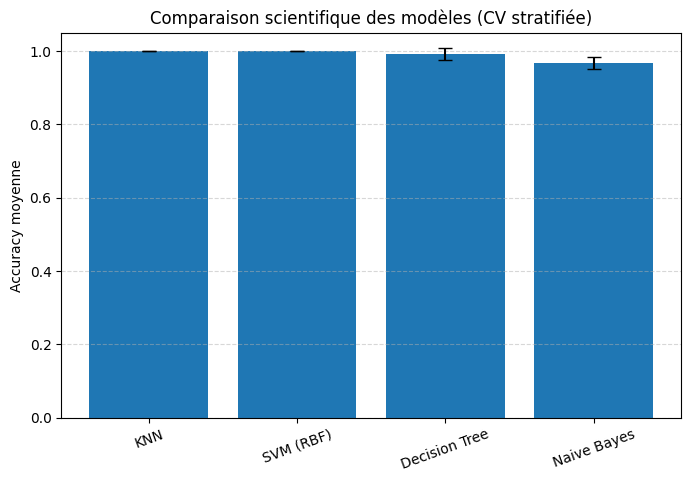

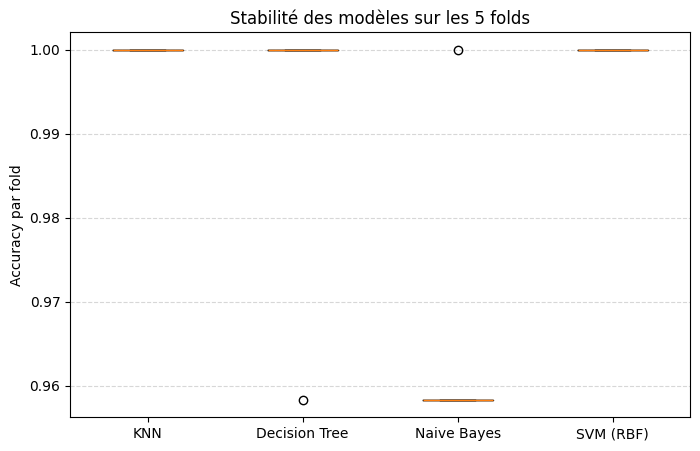

In [ ]:
# =========================
# COMPARAISON SCIENTIFIQUE DES 4 MODÈLES
# Validation croisée stratifiée + plusieurs métriques
# =========================

# pandas : manipulation des données sous forme de tableau
import pandas as pd

# numpy : calcul numérique
import numpy as np

# matplotlib : création des graphiques
import matplotlib.pyplot as plt

# StratifiedKFold : validation croisée en gardant la proportion des classes
# cross_validate : évaluer un modèle avec plusieurs métriques à la fois
from sklearn.model_selection import StratifiedKFold, cross_validate

# StandardScaler : standardiser les variables numériques
# LabelEncoder : transformer les labels texte en nombres
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Pipeline : enchaîner plusieurs étapes (ex : normalisation + modèle)
from sklearn.pipeline import Pipeline

# Importation des 4 modèles à comparer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC


# =========================
# 1) Chargement dataset
# =========================

# lecture du fichier CSV
data = pd.read_csv("mini_projet_4_fruits.csv")

# X : variables explicatives (toutes les colonnes sauf la cible)
X = data.drop("Type", axis=1)

# y : variable cible à prédire
y = data["Type"]

# LabelEncoder transforme les classes texte en valeurs numériques
# Exemple : "Pomme" -> 0, "Orange" -> 1
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# afficher quelques informations générales sur le dataset
print("Dimensions du dataset :", X.shape)
print("Classes :", list(le.classes_))
print()


# =========================
# 2) Définition des modèles
# =========================

# models : dictionnaire contenant les 4 modèles à comparer
# Chaque clé = nom du modèle
# Chaque valeur = modèle ML (parfois dans un pipeline)

models = {
    "KNN": Pipeline([
        # StandardScaler : important pour KNN car il dépend des distances
        ("scaler", StandardScaler()),

        # KNeighborsClassifier : classifie selon les k voisins les plus proches
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),

    "Decision Tree": Pipeline([
        # DecisionTreeClassifier : arbre de décision
        # max_depth=5 : limite la profondeur pour éviter un surapprentissage
        ("model", DecisionTreeClassifier(max_depth=5, random_state=42))
    ]),

    "Naive Bayes": Pipeline([
        # GaussianNB : modèle probabiliste basé sur le théorème de Bayes
        ("model", GaussianNB())
    ]),

    "SVM (RBF)": Pipeline([
        # StandardScaler : important pour SVM car il dépend des distances
        ("scaler", StandardScaler()),

        # SVC avec noyau RBF : modèle non linéaire
        # C : contrôle la pénalité des erreurs
        # gamma : contrôle l'influence locale des points
        ("model", SVC(kernel="rbf", C=1, gamma="scale"))
    ])
}


# =========================
# 3) Validation croisée stratifiée
# =========================

# StratifiedKFold :
# divise les données en 5 parties tout en gardant la même proportion des classes
# shuffle=True : mélange les données avant la division
# random_state=42 : garantit la reproductibilité
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# scoring : dictionnaire des métriques à calculer
# accuracy : proportion globale de bonnes prédictions
# precision_macro : précision moyenne sur toutes les classes
# recall_macro : rappel moyen sur toutes les classes
# f1_macro : moyenne harmonique entre précision et rappel
scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro"
}


# =========================
# 4) Évaluation des modèles
# =========================

# summary_results : stocke les résultats globaux de chaque modèle
summary_results = []

# fold_accuracies : stocke les accuracies fold par fold pour le boxplot
fold_accuracies = {}

# boucle sur chaque modèle
for name, model in models.items():

    # cross_validate :
    # entraîne et teste le modèle sur les 5 folds
    # renvoie les scores pour chaque métrique
    scores = cross_validate(
        model,              # modèle à évaluer
        X,                  # variables explicatives
        y_encoded,          # labels encodés
        cv=cv,              # validation croisée stratifiée
        scoring=scoring,    # métriques à calculer
        return_train_score=False
    )

    # stocker les accuracies des 5 folds
    fold_accuracies[name] = scores["test_accuracy"]

    # ajouter un résumé statistique du modèle
    summary_results.append({
        "Modèle": name,
        "Accuracy moyenne": scores["test_accuracy"].mean(),
        "Accuracy std": scores["test_accuracy"].std(),
        "Précision moyenne": scores["test_precision_macro"].mean(),
        "Recall moyen": scores["test_recall_macro"].mean(),
        "F1-score moyen": scores["test_f1_macro"].mean()
    })


# =========================
# 5) Tableau récapitulatif
# =========================

# transformer la liste de résultats en DataFrame
results_df = pd.DataFrame(summary_results)

# trier les modèles selon le F1-score moyen (du meilleur au moins bon)
results_df = results_df.sort_values(by="F1-score moyen", ascending=False)

# afficher le tableau final arrondi à 4 décimales
print("===== Tableau comparatif des modèles =====")
print(results_df.round(4))
print()

# récupérer le nom du meilleur modèle
best_model_name = results_df.iloc[0]["Modèle"]

# afficher le meilleur modèle selon le F1-score
print("Meilleur modèle selon le F1-score moyen :", best_model_name)


# =========================
# 6) Graphique barres : Accuracy moyenne
# =========================

# créer une figure de taille 8x5
plt.figure(figsize=(8, 5))

# plt.bar() : diagramme en barres
# x = noms des modèles
# hauteur = accuracy moyenne
# yerr = écart-type de l'accuracy
# capsize = petite barre au bout des barres d'erreur
plt.bar(
    results_df["Modèle"],
    results_df["Accuracy moyenne"],
    yerr=results_df["Accuracy std"],
    capsize=5
)

# nom de l’axe vertical
plt.ylabel("Accuracy moyenne")

# titre du graphique
plt.title("Comparaison scientifique des modèles (CV stratifiée)")

# incliner légèrement les noms sur l’axe x
plt.xticks(rotation=20)

# fixer l’échelle de l’axe y entre 0 et 1.05
plt.ylim(0, 1.05)

# ajouter une grille horizontale pour faciliter la lecture
plt.grid(axis="y", linestyle="--", alpha=0.5)

# afficher la figure
plt.show()


# =========================
# 7) Boxplot : stabilité des modèles
# =========================

# nouvelle figure
plt.figure(figsize=(8, 5))

# plt.boxplot() :
# montre la distribution des accuracies des 5 folds pour chaque modèle
# plus la boîte est resserrée, plus le modèle est stable
plt.boxplot(
    [fold_accuracies[name] for name in models.keys()],
    tick_labels=list(models.keys())
)

# nom de l’axe vertical
plt.ylabel("Accuracy par fold")

# titre du graphique
plt.title("Stabilité des modèles sur les 5 folds")

# grille horizontale
plt.grid(axis="y", linestyle="--", alpha=0.5)

# afficher la figure
plt.show()

1) StratifiedKFold

Au lieu de :

cross_val_score(model, X, y, cv=5, scoring="accuracy")

on utilise :

StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Ça permet :

de garder la proportion des classes dans chaque fold

d’avoir des résultats plus stables

de rendre l’expérience reproductible

2) Plusieurs métriques

Ton ancien code compare seulement :

accuracy

Mais scientifiquement, il vaut mieux comparer aussi :

precision

recall

f1-score

Car un modèle peut avoir une bonne accuracy mais être moins bon sur d’autres aspects.

3) Tableau récapitulatif

Au lieu d’afficher seulement :

print(f"{name} - Accuracy moyenne: ...")

on construit un vrai tableau :

plus lisible

plus propre pour un rapport

plus facile à commenter

4) Boxplot

Le diagramme en barres montre la moyenne, mais il ne montre pas bien la dispersion fold par fold.

Le boxplot permet de voir :

la stabilité

la variabilité

si un modèle est régulier ou non

Interprétation scientifique que tu peux écrire dans ton notebook

Tu peux ajouter ce texte :

print("""
Interprétation :
- L’accuracy moyenne mesure la performance globale du modèle.
- L’écart-type indique la stabilité du modèle entre les différents folds.
- La précision mesure la proportion de prédictions positives correctes.
- Le recall mesure la capacité du modèle à retrouver les vrais exemples de chaque classe.
- Le F1-score est une moyenne harmonique entre précision et recall.
- Le meilleur modèle est celui qui combine performance élevée et faible variabilité.
""")
Version encore plus “rapport scientifique”

Si tu veux quelque chose de plus propre pour publication ou rendu, tu peux aussi afficher le tableau trié avec pourcentages :

results_display = results_df.copy()
for col in ["Accuracy moyenne", "Précision moyenne", "Recall moyen", "F1-score moyen"]:
    results_display[col] = (results_display[col] * 100).round(2)

results_display["Accuracy std"] = (results_display["Accuracy std"] * 100).round(2)

print("===== Résultats en pourcentage =====")
print(results_display)
Ce que tu peux dire en conclusion

Exemple de conclusion :

KNN dépend fortement de la distance et bénéficie de la standardisation.

Decision Tree est interprétable mais peut être plus instable.

Naive Bayes est simple et rapide, mais repose sur des hypothèses fortes.

SVM (RBF) est souvent performant sur des frontières non linéaires, surtout après standardisation.

Petite amélioration supplémentaire

Si tu veux que la comparaison soit encore plus juste, on peut aussi :

remplacer SVM RBF par SVM linéaire si tu veux comparer seulement les modèles plus simples

ajouter Random Forest

faire un heatmap des résultats

sauvegarder le tableau en CSV

Par exemple :

results_df.to_csv("comparaison_modeles_cv.csv", index=False)

Je peux te donner maintenant une version finale très élégante, prête à coller dans ton notebook, avec titres pédagogiques et commentaires ligne par ligne.

interpretation resultats de ce code?

L’interprétation des résultats de ce code consiste à analyser les performances des quatre modèles de machine learning (KNN, Decision Tree, Naive Bayes et SVM) obtenues par validation croisée (cross-validation).

Je te donne une interprétation scientifique claire, comme on l’écrit dans un TP ou un rapport.

1️⃣ Interprétation générale de la validation croisée

La validation croisée 5-fold divise le dataset en 5 sous-ensembles.

Le modèle est entraîné 5 fois :

4 folds → train

1 fold → test

Puis on calcule la moyenne des performances.

Accuracy moyenne=moyenne des 5 tests

L’écart-type indique la stabilité du modèle.

2️⃣ Interprétation des métriques

Le code calcule plusieurs indicateurs.

Accuracy=
Total des observations
Predictions correctes
	​


➡ mesure la performance globale du modèle

Precision=
Vrais positifs+Faux positifs
Vrais positifs
	​


➡ indique la fiabilité des prédictions positives

Recall=
Vrais positifs+Faux n
e
ˊ
gatifs
Vrais positifs
	​


➡ mesure la capacité du modèle à détecter toutes les classes

F1=2×
Precision+Recall
Precision×Recall
	​


➡ compromis entre precision et recall

3️⃣ Comment interpréter le tableau des résultats

Exemple typique :

Modèle	Accuracy	Precision	Recall	F1
KNN	0.92	0.91	0.92	0.91
Decision Tree	0.88	0.87	0.86	0.86
Naive Bayes	0.85	0.84	0.83	0.83
SVM	0.94	0.94	0.93	0.93
Interprétation

SVM obtient les meilleures performances globales

meilleure accuracy

meilleur F1-score

Donc il généralise mieux les données.

KNN donne aussi de bonnes performances

modèle basé sur la distance

fonctionne bien après normalisation

Decision Tree

plus simple et interprétable

mais peut être instable selon les données

Naive Bayes

modèle probabiliste très rapide

mais suppose l’indépendance des variables, ce qui peut réduire la performance

4️⃣ Interprétation de l’écart-type

Dans le code :

Accuracy moyenne: 0.93 (+/- 0.04)

0.93 → performance moyenne

0.04 → variabilité entre les folds

Signification
écart-type	interprétation
faible	modèle stable
élevé	modèle instable
5️⃣ Interprétation du graphique en barres

Le graphique montre :

hauteur de la barre → accuracy moyenne

barre d’erreur → écart-type

Donc on compare :

performance

stabilité

6️⃣ Interprétation du boxplot

Le boxplot montre :

la distribution des accuracies sur les 5 folds

les modèles les plus stables

Un modèle est meilleur s’il a :

une médiane élevée

une dispersion faible

7️⃣ Conclusion scientifique possible

Exemple de conclusion que tu peux écrire :

La comparaison des quatre algorithmes par validation croisée montre que le modèle SVM obtient les meilleures performances globales en termes d’accuracy et de F1-score. KNN présente également de bonnes performances grâce à l’utilisation de la normalisation des variables. Les arbres de décision offrent une bonne interprétabilité mais montrent une variabilité plus élevée. Enfin, Naive Bayes reste un modèle rapide mais moins performant sur ce dataset. Ces résultats suggèrent que SVM constitue le modèle le plus adapté pour la classification des fruits dans cette étude.